# Figures

## Used libraries

In [1]:
import pandas as pd
from pathlib import Path
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Read samples:

In [2]:
data = pd.read_pickle('../../results/dataframe_spectrum_thickness_161.pkl')

In [3]:
data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO01-1,ANZO011M,141.565084,18.100000,10.925087,"[[[0.037], [0.078], [0.045], [0.092], [0.049],..."
2,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
3,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
4,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."


In [4]:
data.head(10)

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO01-1,ANZO011M,141.565084,18.100000,10.925087,"[[[0.037], [0.078], [0.045], [0.092], [0.049],..."
2,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
3,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
4,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."
5,AZO3Min,AZO3MINM,224.897289,14.052483,5.072915,"[[[0.071], [0.101], [0.002], [0.084], [0.04], ..."
6,AZO3Min3,AZO3MI3M,228.881195,7.236276,2.569700,"[[[0.072], [0.122], [0.049], [0.069999], [0.04..."
7,ANZO01-2,ANZO012M,246.587444,30.200000,10.789327,"[[[0.064], [0.063], [0.039], [0.083], [0.034],..."
8,ANZO31,ANZO31M,301.355303,74.230000,20.331416,"[[[0.055], [0.116], [0.044], [0.072], [0.076],..."
9,AZO5X,AZO5XM,337.635755,95.608096,23.496706,"[[[0.02], [0.098], [0.054], [0.079], [0.036], ..."


In [5]:
ind1 = np.load('./indexes/outlier_indices_16.npy')
#ind2 = np.load('./indexes/ind2.npy')[0]
ind1.shape #, ind2.shape

(16,)

In [6]:
_data = data.drop(ind1).reset_index(drop=True)
#_data = data.iloc[ind1].reset_index(drop = True)
#__data = _data.iloc[ind2].reset_index(drop = True)

In [7]:
_data.shape

(145, 6)

In [8]:
data = _data
data.head()

,Nombre,Nombre-Arc,Espesor,Error,Error Porcentual,Espectro
0,ANZO32,ANZO32M,91.223787,12.300000,10.000000,"[[[0.071], [0.058], [0.055999], [0.08], [0.055..."
1,ANZO30,ANZO30M,167.256504,21.600000,10.256410,"[[[0.006999], [0.102], [0.029], [0.08], [0.035..."
2,ANZO35,ANZO35M,167.777276,21.100000,9.990530,"[[[0.066], [0.097], [0.023], [0.078], [0.047],..."
3,AZO3Min2,AZO3MI2M,224.029336,8.740362,3.166683,"[[[0.063], [0.091], [0.024], [0.066], [0.063],..."
4,AZO3Min,AZO3MINM,224.897289,14.052483,5.072915,"[[[0.071], [0.101], [0.002], [0.084], [0.04], ..."


In [9]:
np.mean(data['Error Porcentual'])

np.float64(9.607537774786207)

## Thickness Distribution:

In [10]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely
})

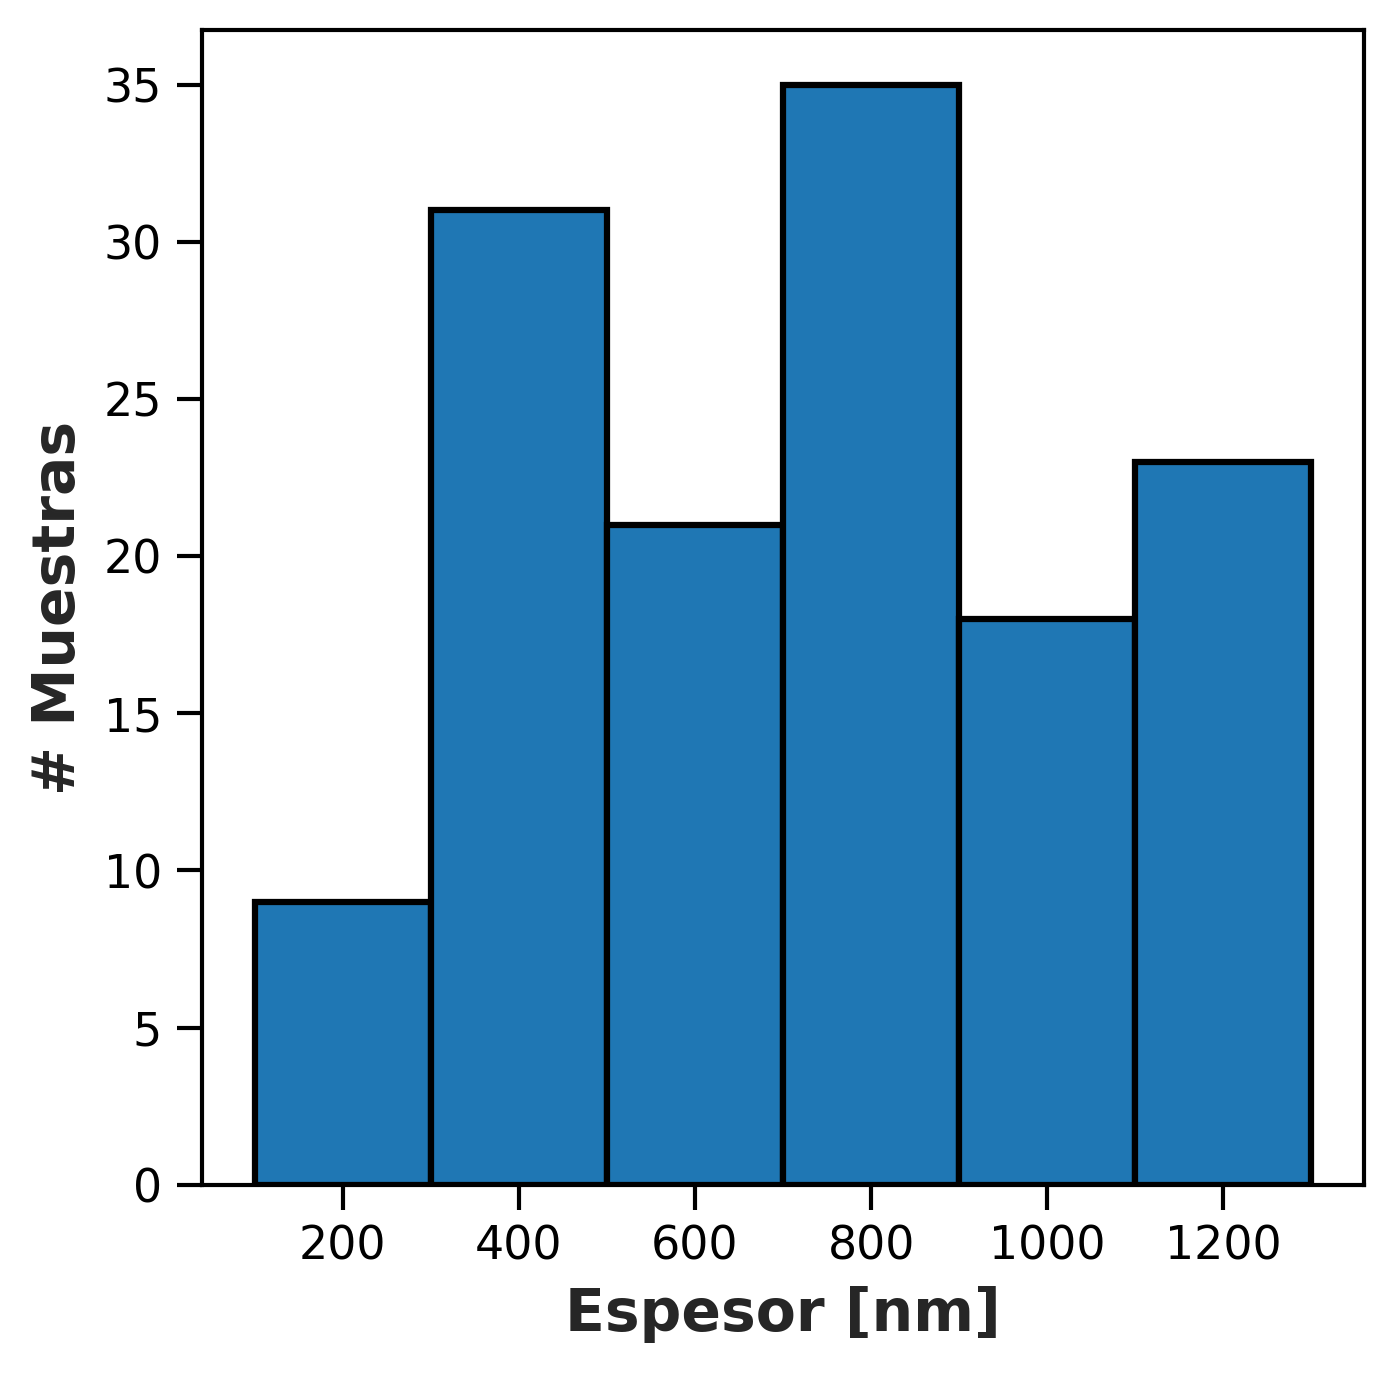

In [11]:
plt.figure(figsize = (5,5))
bins = np.arange(
    100, 
    1500, 
    200)
plt.hist(data['Espesor'], bins=bins, edgecolor = 'black')
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
plt.savefig('./images/bin_200.png')
plt.show()

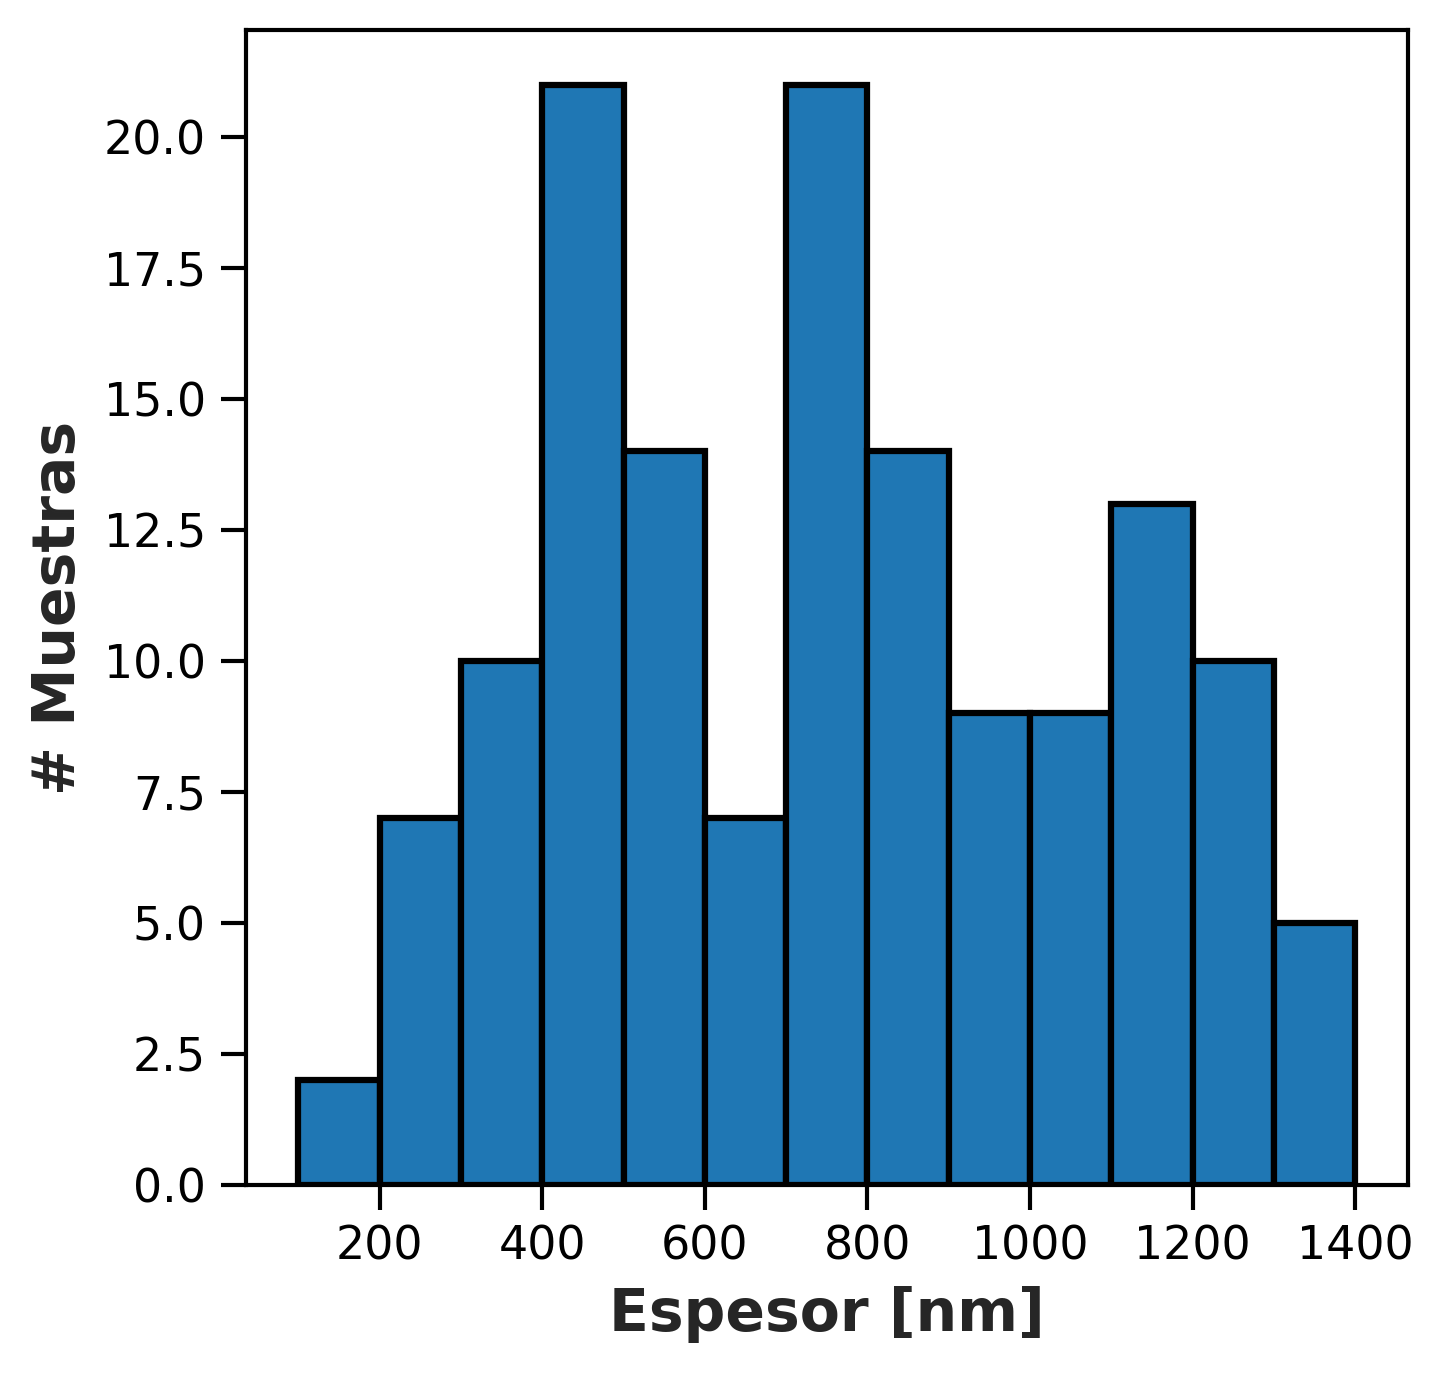

In [12]:
plt.figure(figsize = (5,5))
bins = np.arange(
    100, 
    1500, 
    100)
plt.hist(data['Espesor'], bins=bins, edgecolor = 'black')
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
plt.savefig('./images/bin_100.png')
plt.show()

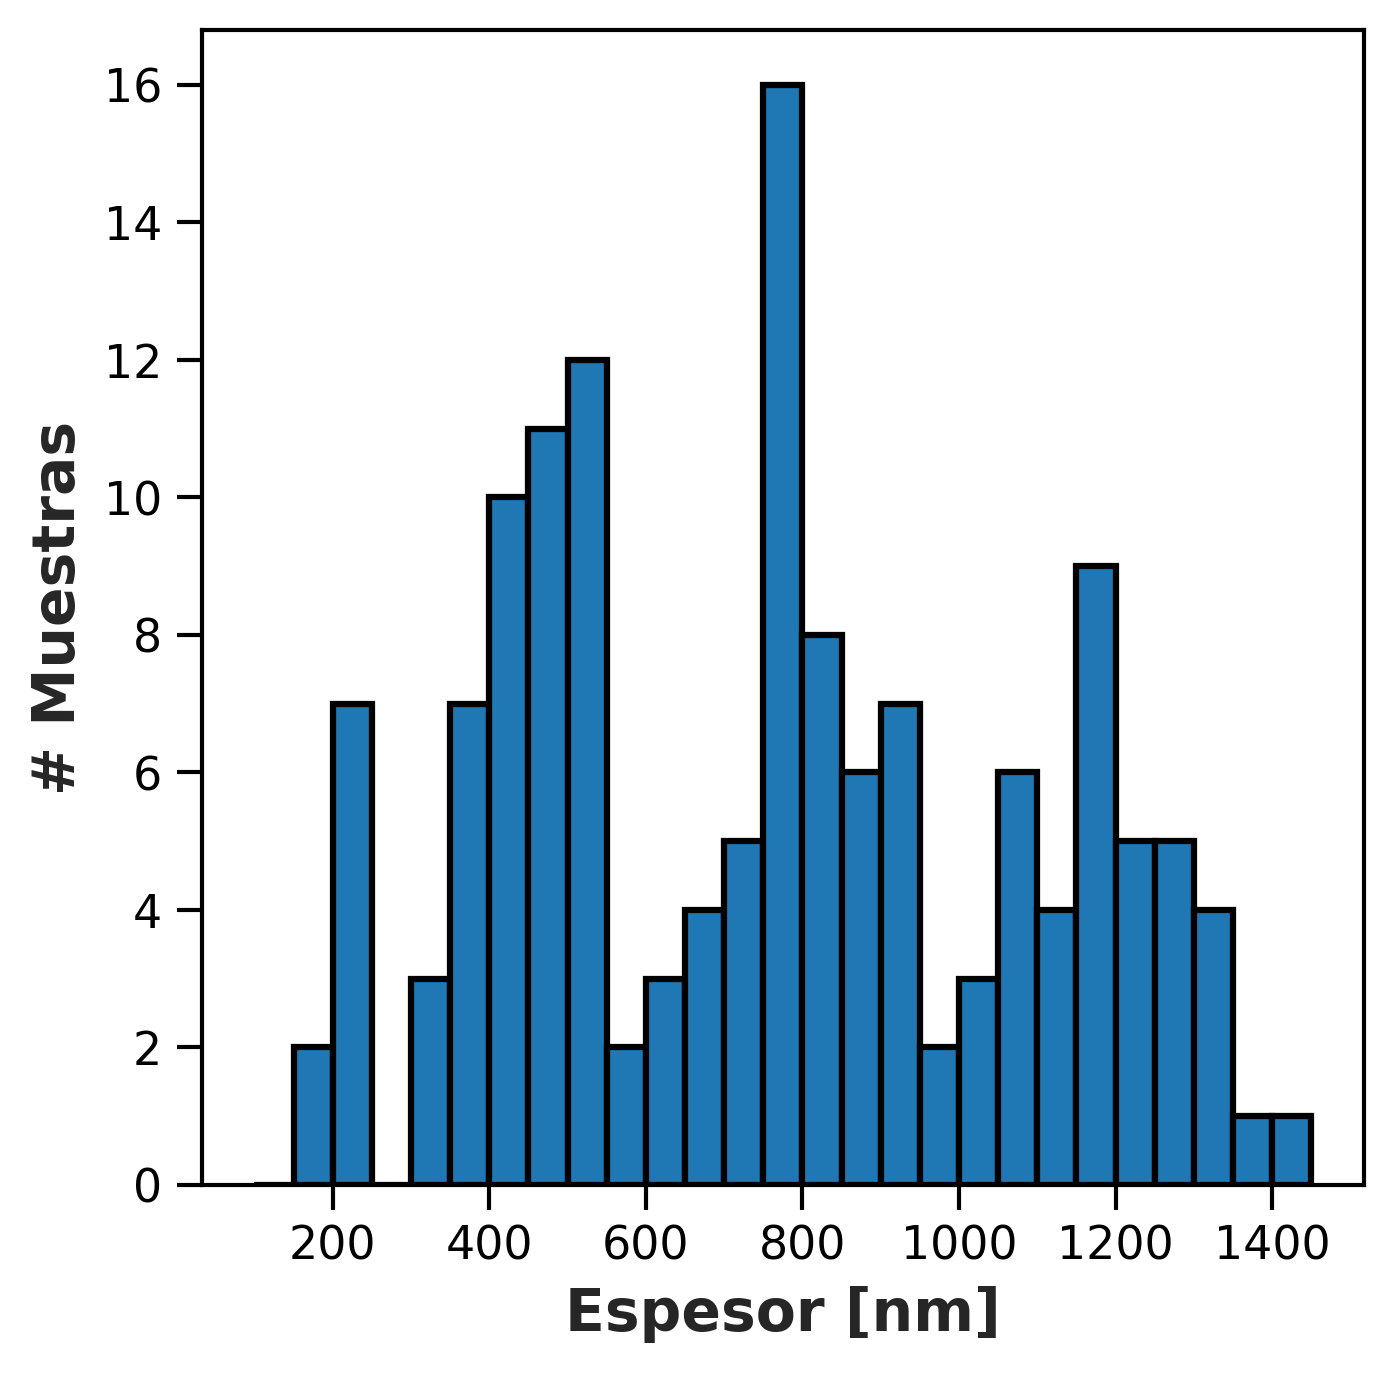

In [13]:
plt.figure(figsize = (5,5))
bins = np.arange(
    100, 
    1500, 
    50)
plt.hist(data['Espesor'], bins=bins, edgecolor = 'black')
plt.ylabel('# Muestras')
plt.xlabel('Espesor [nm]')
plt.savefig('./images/bin_50.png')
plt.show()

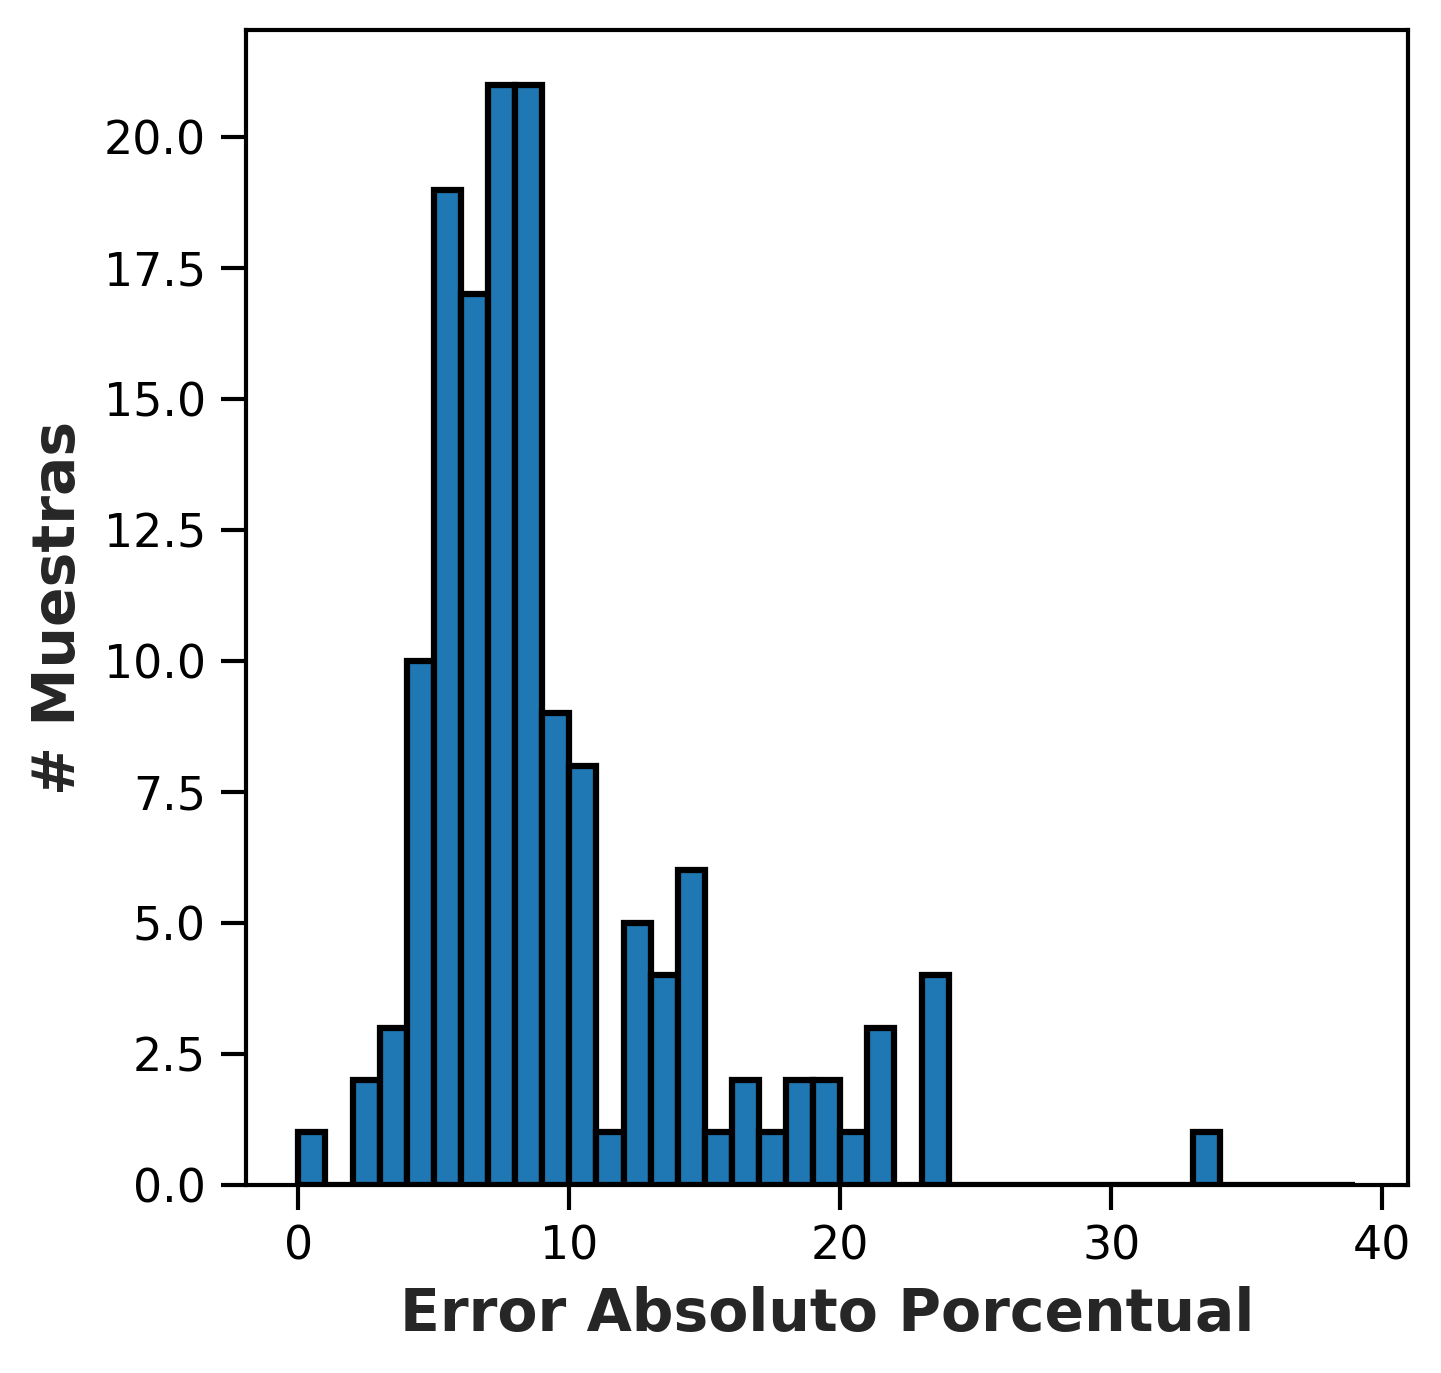

In [14]:
plt.figure(figsize = (5,5))
bins = np.arange(
    0, 
    40, 
    1)
plt.hist(data['Error Porcentual'], bins=bins, edgecolor = 'black')
plt.ylabel('# Muestras')
plt.xlabel('Error Absoluto Porcentual')
plt.savefig('./images/error1.png')
plt.show()

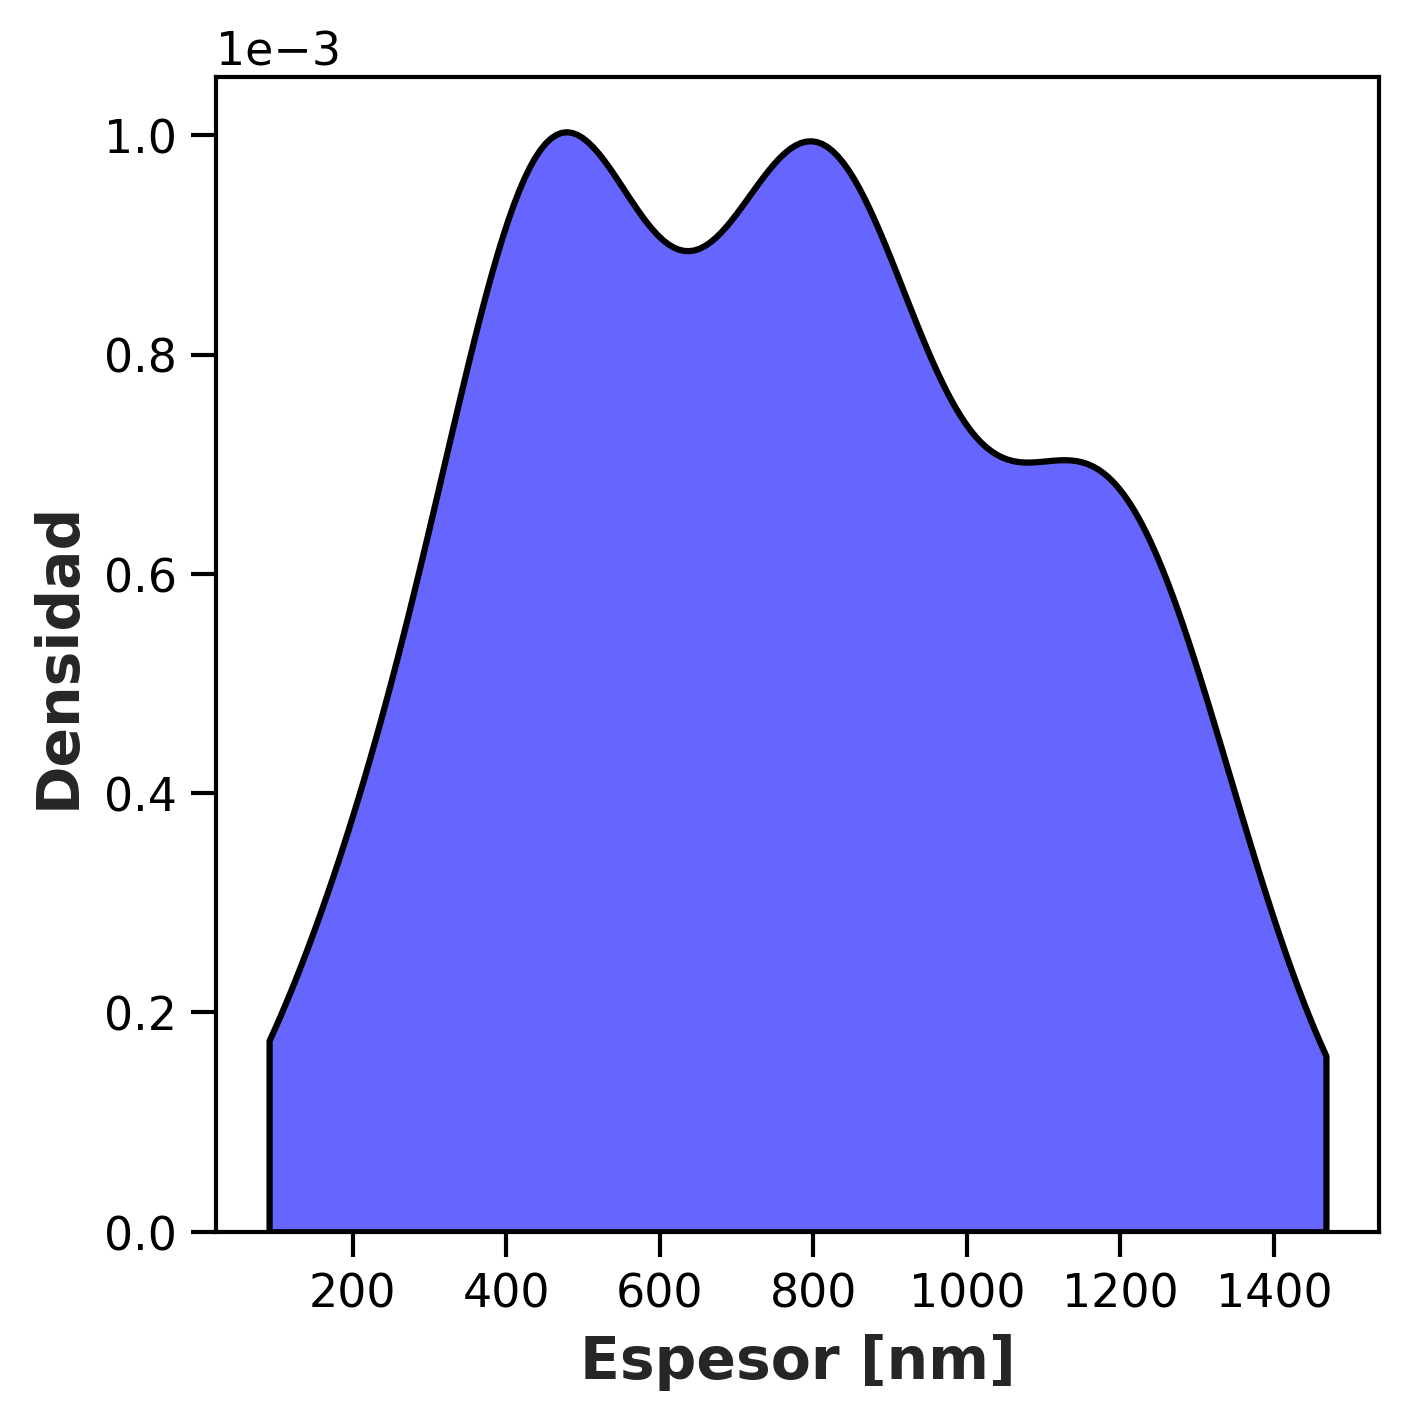

In [15]:
plt.figure(figsize = (5,5))
sns.kdeplot(data['Espesor'], fill = True, color= 'blue', edgecolor = 'black', alpha = 0.6, 
            clip= [np.min(data['Espesor']), 
                  np.max(data['Espesor'])] 
           )
#plt.xlim(np.min(data['Espesor']), (np.max(data['Espesor'])))
plt.ylabel('Densidad')
plt.xlabel('Espesor [nm]')

# Scale Y-axis to 1e-3
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax = plt.gca()
#ax.yaxis.get_offset_text().set_text('×10⁻3')  # Customize the multiplier text
# Or use: ax.yaxis.offsetText.set_text('×10⁻³')


plt.savefig('./images/kde.png')
plt.show()

In [16]:
data.to_pickle('../../results/dataframe_spectrum_thickness_145_final.pkl')